In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/spectro/redux/everest/exposures-everest.fits', ext='EXPOSURES'))
print(len(cat), len(np.unique(cat['EXPID'])))

tileid_list = [80605, 80606, 80607, 80608, 80609, 80610, 80613]

mask = np.in1d(cat['TILEID'], tileid_list)
cat = cat[mask]
print(len(cat), len(np.unique(cat['EXPID'])))
cat.sort('EXPID')

cat[:1]

3912 3912
199 199


NIGHT,EXPID,TILEID,TILERA,TILEDEC,MJD,SURVEY,FAPRGRM,FAFLAVOR,EXPTIME,EFFTIME_SPEC,GOALTIME,GOALTYPE,MINTFRAC,AIRMASS,EBV,SEEING_ETC,EFFTIME_ETC,TSNR2_ELG,TSNR2_QSO,TSNR2_LRG,TSNR2_LYA,TSNR2_BGS,TSNR2_GPBDARK,TSNR2_GPBBRIGHT,TSNR2_GPBBACKUP,ELG_EFFTIME_DARK,BGS_EFFTIME_BRIGHT,LYA_EFFTIME_DARK,GPB_EFFTIME_DARK,GPB_EFFTIME_BRIGHT,GPB_EFFTIME_BACKUP,TRANSPARENCY_GFA,SEEING_GFA,FIBER_FRACFLUX_GFA,FIBER_FRACFLUX_ELG_GFA,FIBER_FRACFLUX_BGS_GFA,FIBERFAC_GFA,FIBERFAC_ELG_GFA,FIBERFAC_BGS_GFA,AIRMASS_GFA,SKY_MAG_AB_GFA,SKY_MAG_G_SPEC,SKY_MAG_R_SPEC,SKY_MAG_Z_SPEC,EFFTIME_GFA,EFFTIME_DARK_GFA,EFFTIME_BRIGHT_GFA,EFFTIME_BACKUP_GFA
int32,int32,int32,float64,float64,float64,str7,str16,str19,float64,float32,float64,str7,float64,float32,float64,float64,float32,float32,float32,float32,float64,float32,float32,float32,float32,float32,float32,float64,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20201214,67710,80605,36.448,-4.601,59198.17546592,cmx,lrgqso,cmxlrgqso,900.0768432617188,17.678322,0.0,dark,0.9,1.244535,0.027954712510108948,0.0,0.0,2.0556188,0.50336325,1.3653402,1.3002506535412977,129.76926,183.51768,37.121105,323.46216,17.678322,18.167696,14.874552855509554,15.886618,19.497217,23.706322,0.8492798487032461,3.564885312205003,0.09986733788074378,0.09224460376713113,0.05081245578836019,0.13819053540936618,0.17575265339537782,0.21049699242953124,1.2455698627435972,20.240443909109267,22.13921719549746,21.13632370601902,19.34183746610626,24.223214032423588,24.223214032423588,34.68641181871453,14.899105361791909


In [4]:
mask_bgs = cat['TILEID']==80613
mask_bgs &= cat['BGS_EFFTIME_BRIGHT']/cat['EXPTIME'] > 0.2

mask_dark = cat['TILEID']!=80613
mask_dark &= cat['EFFTIME_SPEC']/cat['EXPTIME'] > 0.3

mask = mask_bgs | mask_dark
cat = cat[mask]
print(len(cat))

97


14 83


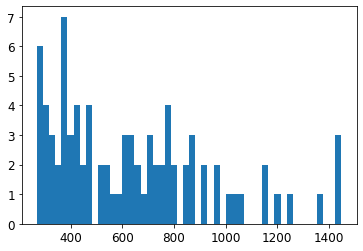

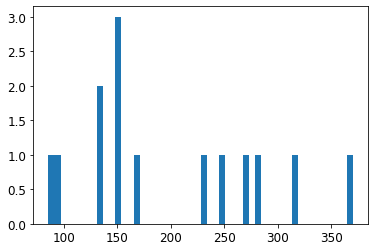

In [5]:
mask_bright = cat['TILEID']==80613
mask_dark = cat['TILEID']!=80613

print(np.sum(mask_bright), np.sum(mask_dark))

plt.hist(cat['EFFTIME_SPEC'][mask_dark], 50)
plt.show()

plt.hist(cat['BGS_EFFTIME_BRIGHT'][mask_bright], 50)
plt.show()

In [6]:
# Remove the BGS tile
mask_bgs = cat['TILEID']==80613
cat = cat[~mask_bgs]
print(len(cat))

83


In [7]:
# Only keep <1x exposures
mask = (cat['EFFTIME_SPEC']<850)
cat = cat[mask]
print(len(cat))

63


In [8]:
for tileid in np.unique(cat['TILEID']):
    mask = cat['TILEID']==tileid
    if tileid==80613:
        print(tileid, np.sum(cat['BGS_EFFTIME_BRIGHT'][mask]), np.sum(mask), cat['FAPRGRM'][mask][0])
    else:
        print(tileid, np.sum(cat['EFFTIME_SPEC'][mask]), np.sum(mask), cat['FAPRGRM'][mask][0])

80605 5188.382 10 lrgqso
80606 3069.1025 7 elg
80607 5355.4385 11 lrgqso
80608 6305.366 12 elg
80609 6781.8745 13 lrgqso
80610 4999.291 10 elg


In [9]:
for tileid in np.unique(cat['TILEID']):
    mask = cat['TILEID']==tileid
    if tileid==80613:
        print('{} {:.0f} {:.1f}'.format(tileid, np.sum(cat['BGS_EFFTIME_BRIGHT'][mask]), np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])/180.))
    else:
        print('{} {:.0f} {:.1f}'.format(tileid, np.sum(cat['EFFTIME_SPEC'][mask]), np.sum(cat['EFFTIME_SPEC'][mask])/1000.))

80605 5188 5.2
80606 3069 3.1
80607 5355 5.4
80608 6305 6.3
80609 6782 6.8
80610 4999 5.0


In [10]:
print('TILEID n_exp tot_depth n_sub_min n_sub_max  n_sub')
for tileid in np.unique(cat['TILEID']):
    mask = cat['TILEID']==tileid
    if tileid==80613:
        nom_depth = 180.
        tot_depth = np.sum(cat['BGS_EFFTIME_BRIGHT'][mask])
    else:
        nom_depth = 1000.
        tot_depth = np.sum(cat['EFFTIME_SPEC'][mask])
    n_sub_min = tot_depth/nom_depth
    if n_sub_min < 2:
        margin = 0.15
    else:
        margin = 0.1
    n_sub_max = tot_depth/(nom_depth*(1-margin))
    n_sub = int(np.floor(n_sub_max))
    print(tileid, '{:3} {:12.2f} {:9.2f} {:9.2f} {:6}'.format(np.sum(mask), tot_depth, n_sub_min, n_sub_max, n_sub))

TILEID n_exp tot_depth n_sub_min n_sub_max  n_sub
80605  10      5188.38      5.19      5.76      5
80606   7      3069.10      3.07      3.41      3
80607  11      5355.44      5.36      5.95      5
80608  12      6305.37      6.31      7.01      7
80609  13      6781.87      6.78      7.54      7
80610  10      4999.29      5.00      5.55      5


----

In [11]:
np.random.seed(511)

subsamp_dict = {}

# tileid = 80607
for tileid in np.unique(cat['TILEID']):
    
    print()
    
    if tileid==80613:
        nom_depth = 180.
        depth_col = 'BGS_EFFTIME_BRIGHT'
    else:
        nom_depth = 1000.
        depth_col = 'EFFTIME_SPEC'
    mask = cat['TILEID']==tileid

    n_exp = np.sum(mask)

    tot_depth = np.sum(cat[depth_col][mask])
    # n_sub_min = tot_depth/nom_depth
    # if n_sub_min < 2:
    #     margin = 0.15
    # else:
    #     margin = 0.1
    print(tileid, '{:3} {:.0f}'.format(np.sum(mask), tot_depth, n_exp))

    mask = cat['TILEID']==tileid
    expid_list = np.array(cat['EXPID'][mask])
    subsets = []
    n_exp_used = 0
    total_iteration = 0
    n_exp_min = n_exp + 1
    
    while True:
        
        total_iteration += 1

        if total_iteration%300==1:
            n_exp_min -= 1
            margin = 0.05  # initial margin
            print('total_iteration={};  n_exp_min={}'.format(total_iteration, n_exp_min))
        if (total_iteration%300)==100:
            margin = 0.1
        if (total_iteration%300)==200:
            margin = 0.15

        success = False
        iteration = 0
        while success==False:
            iteration += 1
            subset = []
            subset_depth = []
            while True:
                mask = ~np.in1d(expid_list, subset)
                expid = np.random.choice(expid_list[mask])
                subset.append(expid)
                subset_depth.append(cat[depth_col][cat['EXPID']==expid][0])
                if (np.sum(subset_depth)>(1-margin)*nom_depth) and (np.sum(subset_depth)<(1+margin)*nom_depth):
                    if len(subset)!=1:  # require 2+ exposures for the coadd
                        success = True
                    # print(np.sum(subset_depth))
                    break
                if len(subset)==len(expid_list):
                    break
            if iteration>(np.minimum(100, np.math.factorial(n_exp))):
                # reset
                mask = cat['TILEID']==tileid
                expid_list = np.array(cat['EXPID'][mask])
                subsets = []
                n_exp_used = 0
                break
        if success:
            subsets.append(subset)
            n_exp_used += len(subset)
            mask = ~np.in1d(expid_list, np.concatenate(subsets))
            expid_list = expid_list[mask]
        if n_exp_used>=n_exp_min:
            break
    
    print('Final number of iterations: {}'.format(total_iteration))
    print('Tile', tileid, subsets)
    subsamp_dict[str(tileid)] = subsets
    for subset in subsets:
        mask = np.in1d(cat['EXPID'], subset)
        print(np.sum(mask), np.sum(cat[depth_col][mask]))


80605  10 5188
total_iteration=1;  n_exp_min=10
Final number of iterations: 202
Tile 80605 [[74781, 73702], [67975, 74782], [68292, 74779], [68291, 68290], [74783, 74780]]
2 950.5128
2 1034.6511
2 1103.0221
2 1118.1396
2 982.05566

80606   7 3069
total_iteration=1;  n_exp_min=7
Final number of iterations: 205
Tile 80606 [[68630, 67968], [67971, 68812], [67969, 68813, 67970]]
2 1051.7473
2 898.08875
3 1119.2662

80607  11 5355
total_iteration=1;  n_exp_min=11
Final number of iterations: 206
Tile 80607 [[67768, 68844], [68027, 68845], [67767, 68028, 67766], [68847, 67744], [67765, 68846]]
2 1077.6661
2 1073.04
3 1081.1959
2 1084.2583
2 1039.2781

80608  12 6305
total_iteration=1;  n_exp_min=12
Final number of iterations: 278
Tile 80608 [[68025, 68328], [67770, 68026], [67771, 68327], [67769, 68024], [68842, 68023], [68491, 68841]]
2 1048.3462
2 1130.4744
2 1135.3237
2 948.8429
2 962.6979
2 1079.681

80609  13 6782
total_iteration=1;  n_exp_min=13
total_iteration=301;  n_exp_min=12
Final

In [16]:
subsamp_dict

{'80605': [[74781, 73702],
  [67975, 74782],
  [68292, 74779],
  [68291, 68290],
  [74783, 74780]],
 '80606': [[68630, 67968], [67971, 68812], [67969, 68813, 67970]],
 '80607': [[67768, 68844],
  [68027, 68845],
  [67767, 68028, 67766],
  [68847, 67744],
  [67765, 68846]],
 '80608': [[68025, 68328],
  [67770, 68026],
  [67771, 68327],
  [67769, 68024],
  [68842, 68023],
  [68491, 68841]],
 '80609': [[68489, 67781],
  [67784, 68338],
  [68336, 68490],
  [68064, 68334],
  [68340, 67783],
  [68063, 68065]],
 '80610': [[68333, 68477],
  [68332, 68331],
  [68330, 68042],
  [68488, 68041],
  [68040, 75116]]}

In [11]:
subsamp_dict = {'80605': [[74781, 73702],
  [67975, 74782],
  [68292, 74779],
  [68291, 68290],
  [74783, 74780]],
 '80606': [[68630, 67968], [67971, 68812], [67969, 68813, 67970]],
 '80607': [[67768, 68844],
  [68027, 68845],
  [67767, 68028, 67766],
  [68847, 67744],
  [67765, 68846]],
 '80608': [[68025, 68328],
  [67770, 68026],
  [67771, 68327],
  [67769, 68024],
  [68842, 68023],
  [68491, 68841]],
 '80609': [[68489, 67781],
  [67784, 68338],
  [68336, 68490],
  [68064, 68334],
  [68340, 67783],
  [68063, 68065]],
 '80610': [[68333, 68477],
  [68332, 68331],
  [68330, 68042],
  [68488, 68041],
  [68040, 75116]]}

In [15]:
# Print summary
for tileid_str in subsamp_dict.keys():
    tileid = int(tileid_str)
    mask = cat['TILEID']==tileid
    tile_flavor = cat['FAPRGRM'][mask][0].upper()
    n_exp = np.sum(mask)
    if tileid==80613:
        nom_depth = 180.
        depth_col = 'BGS_EFFTIME_BRIGHT'
    else:
        nom_depth = 1000.
        depth_col = 'EFFTIME_SPEC'
    tot_depth = np.sum(cat[depth_col][mask])
    print('Tile {} ({}):'.format(tileid, tile_flavor))
    print('all:       n_exp={:2}  {}={:5.0f}s'.format(n_exp, depth_col, tot_depth))
    subsets = subsamp_dict[tileid_str]
    for index, subset in enumerate(subsets):
        mask = np.in1d(cat['EXPID'], subset)
        subset_depth = np.sum(cat[depth_col][mask])
        print('subset {}:  n_exp={:2}  {}={:5.0f}s'.format(index+1, len(subset), depth_col, subset_depth))
    mask = (cat['TILEID']==tileid) & (~np.in1d(cat['EXPID'], np.concatenate(subsets)))
    unused_depth = np.sum(cat[depth_col][mask])
    print('unused:    n_exp={:2}  {}={:5.0f}s'.format(np.sum(mask), depth_col, unused_depth))
    print()

Tile 80605 (LRGQSO):
all:       n_exp=10  EFFTIME_SPEC= 5188s
subset 1:  n_exp= 2  EFFTIME_SPEC=  951s
subset 2:  n_exp= 2  EFFTIME_SPEC= 1035s
subset 3:  n_exp= 2  EFFTIME_SPEC= 1103s
subset 4:  n_exp= 2  EFFTIME_SPEC= 1118s
subset 5:  n_exp= 2  EFFTIME_SPEC=  982s
unused:    n_exp= 0  EFFTIME_SPEC=    0s

Tile 80606 (ELG):
all:       n_exp= 7  EFFTIME_SPEC= 3069s
subset 1:  n_exp= 2  EFFTIME_SPEC= 1052s
subset 2:  n_exp= 2  EFFTIME_SPEC=  898s
subset 3:  n_exp= 3  EFFTIME_SPEC= 1119s
unused:    n_exp= 0  EFFTIME_SPEC=    0s

Tile 80607 (LRGQSO):
all:       n_exp=11  EFFTIME_SPEC= 5355s
subset 1:  n_exp= 2  EFFTIME_SPEC= 1078s
subset 2:  n_exp= 2  EFFTIME_SPEC= 1073s
subset 3:  n_exp= 3  EFFTIME_SPEC= 1081s
subset 4:  n_exp= 2  EFFTIME_SPEC= 1084s
subset 5:  n_exp= 2  EFFTIME_SPEC= 1039s
unused:    n_exp= 0  EFFTIME_SPEC=    0s

Tile 80608 (ELG):
all:       n_exp=12  EFFTIME_SPEC= 6305s
subset 1:  n_exp= 2  EFFTIME_SPEC= 1048s
subset 2:  n_exp= 2  EFFTIME_SPEC= 1130s
subset 3:  n_exp=